## Keep a proportion of papers per topic and classify by citation and type
* Keep "review" articles (either `document_type=='review'` or review is in title)
* Classify according to number of citations

In [ ]:
import ast
import re

# Size of paper dataset for each topic
paper_dataset_per_topic = 0.15

# Minimum year for keeping a document
min_year = 2020

#topic_size = 30
#min_samples = 2

neighbors = 10
components = 15

input_dir = f"./SPECTER_2/INCLUDED/{doc_type.upper()}/neighbors={neighbors}_components={components}/{hdbscan_cluster_method.upper()}"

for topic_size, min_samples in zip([32], [2]):
    topic_info = pd.read_csv(input_dir +
                                f"/topic_info_topic_size={topic_size}_min_samples={min_samples}.csv", index_col=0)

    filepath1 = (f"./TOPIC_RESULTS/review_selection_topic_info_min_topic_size={topic_size}_min_samples" + 
                 f"={min_samples}_neighbors={neighbors}_components={components}.txt")

    filepath2 = (f"./TOPIC_RESULTS/paper_selection_topic_info_min_topic_size={topic_size}_min_samples" +
                 f"={min_samples}_neighbors={neighbors}_components={components}.txt")
    
    with open(filepath1, 'w') as file, open(filepath2, 'w') as file2:

        for topic_nb in topic_info.index:
            if topic_nb > 0:

                nb_docs = round(paper_dataset_per_topic * topic_info.loc[topic_nb, "Count"])
                print(nb_docs)
                
                topic_repr = ast.literal_eval(topic_info.loc[topic_nb, "Representation"])
                titles = ast.literal_eval(re.sub(r"\n", ",", topic_info.loc[topic_nb, "repr_doc_titles"]))
                abstracts = ast.literal_eval(re.sub(r"\n", ",", topic_info.loc[topic_nb, "repr_doc_abstracts"]))
                document_type = ast.literal_eval(re.sub(r"'\s+'", "','", topic_info.loc[topic_nb, "repr_doc_types"]))

                ###
                year = ast.literal_eval(re.sub(r"(?<=[n\d\.])\s+", ",", topic_info.loc[topic_nb, "repr_doc_year"]))
                citation_count_regex = re.sub(r"(?<=[n\d\.])\s+", ",", topic_info.loc[topic_nb, "repr_doc_citation_count"])
                citation_count = ast.literal_eval(re.sub("nan", "0.", citation_count_regex))
                doi_doc = ast.literal_eval(re.sub(r"\s+", ",", topic_info.loc[topic_nb, "repr_doc_dois"]))

                ## Selection
                selection = {"titles": [val for y, val in sorted(zip(year, titles), reverse=True) if y >= min_year],
                             "doc_type": [val for y, val in sorted(zip(year, document_type), reverse=True) if y >= min_year],
                             "doi": [val for y, val in sorted(zip(year, doi_doc), reverse=True) if y >= min_year],
                             "year": [y for y in sorted(year, reverse=True) if y >= min_year],
                             "citation_count": [val for y, val in sorted(zip(year, citation_count), reverse=True) if y >= min_year]                    
                }

                ## Reviews
                review_selection = {
                    "titles": [title for doc, title in zip(selection["doc_type"], selection["titles"]) 
                               if doc.lower() == "review" or "review" in title],
                    "doc_type": [doc for doc, title in zip(selection["doc_type"], selection["titles"]) 
                                 if doc.lower() == "review" or "review" in title],
                    "doi": [doi for doi, doc, title in zip(selection["doi"], selection["doc_type"], selection["titles"]) 
                               if doc.lower() == "review" or "review" in title],
                    "year": [year for year, doc, title in zip(selection["year"], selection["doc_type"], selection["titles"]) 
                             if doc.lower() == "review" or "review" in title],
                    "citation_count": [c for c, doc, title in zip(selection["citation_count"],
                                                                  selection["doc_type"], selection["titles"]) 
                                       if doc.lower() == "review" or "review" in title]
                }

                # Select papers by citation count
                selection_by_citation = {
                    "titles": [val for i, (c, val) in 
                               enumerate(sorted(zip(selection["citation_count"], 
                                                    selection["titles"]), reverse=True)) if i <= nb_docs - 1],
                    "doc_type": [val for i, (c, val) in 
                                 enumerate(sorted(zip(selection["citation_count"], 
                                                      selection["doc_type"]), reverse=True)) if i <= nb_docs - 1],
                    "doi": [val for i, (c, val) in 
                            enumerate(sorted(zip(selection["citation_count"], 
                                                 selection["doi"]), reverse=True)) if i <= nb_docs - 1],
                    "year": [val for i, (c, val) in 
                             enumerate(sorted(zip(selection["citation_count"], 
                                                  selection["year"]), reverse=True)) if i <= nb_docs - 1],
                    "citation_count": [val for i, val in 
                               enumerate(sorted(selection["citation_count"],
                                                reverse=True)) if i <= nb_docs - 1]
                }


                # title_type_doi_year_citation = [f"TITLE: {title} -- DOI: {doi} -- TYPE: {_type} -- YEAR: {y} -- CITATION COUNT: {c}" 
                #                                 for (title, _type, doi, y, c) in 
                #                                 zip(review_selection["titles"], review_selection["doc_type"],
                #                                     review_selection["doi"], review_selection["year"],
                #                                     review_selection["citation_count"])]

                # title_type_doi_year_citation2 = [f"TITLE: {title} -- DOI: {doi} -- TYPE: {_type} -- YEAR: {y} -- CITATION COUNT: {c}" 
                #                                  for (title, _type, doi, y, c) in 
                #                                  zip(selection_by_citation["titles"], selection_by_citation["doc_type"],
                #                                      selection_by_citation["doi"], selection_by_citation["year"],
                #                                      selection_by_citation["citation_count"])]

                ###
                for outfile, sel in zip([file, file2], [review_selection, selection_by_citation]):

                    title_type_doi_year_citation = [f"TITLE: {title} -- DOI: {doi} -- TYPE: {_type} -- YEAR: {y} -- CITATION COUNT: {c}" 
                                                for (title, _type, doi, y, c) in 
                                                zip(sel["titles"], sel["doc_type"],
                                                    sel["doi"], sel["year"],
                                                    sel["citation_count"])]
                    
                    print("--------", file=outfile)
                    print(f'Topic {topic_nb} : nb of docs = {topic_info.loc[topic_nb, "Count"]}', file=outfile)
                    print(f'Representation: {", ".join(topic_repr)}', file=outfile)
                    print(f'{"\n".join(title_type_doi_year_citation)}\n', file=outfile)
                    print("\n", file=outfile)

---

# Nb of articles per topic over time

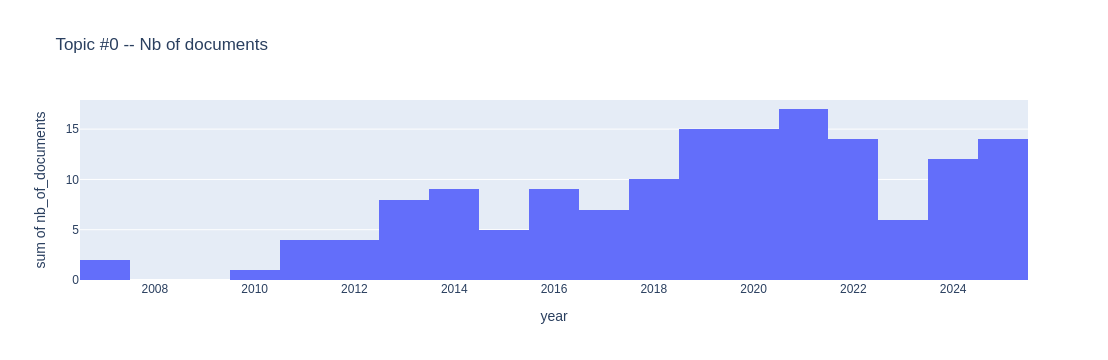

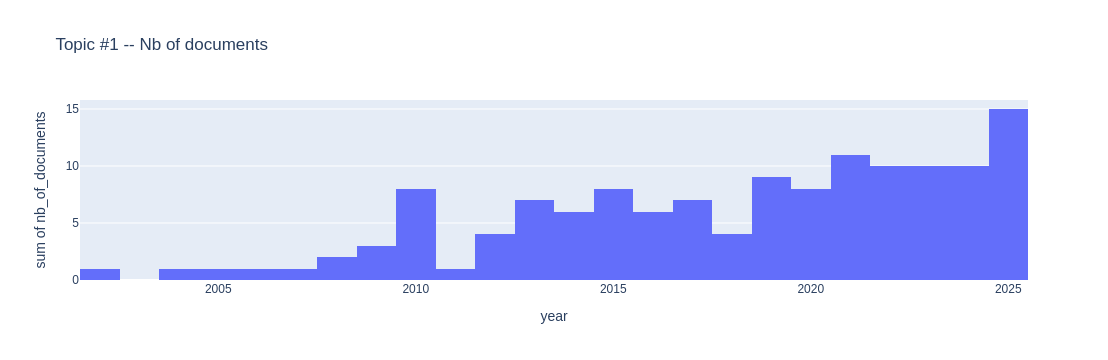

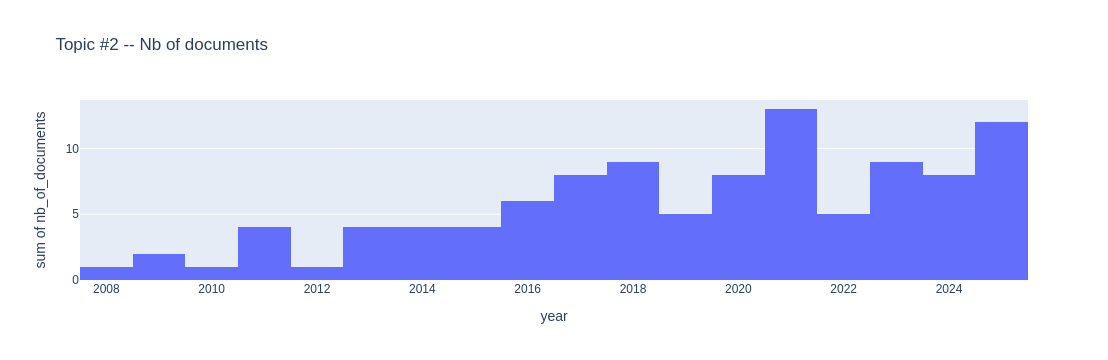

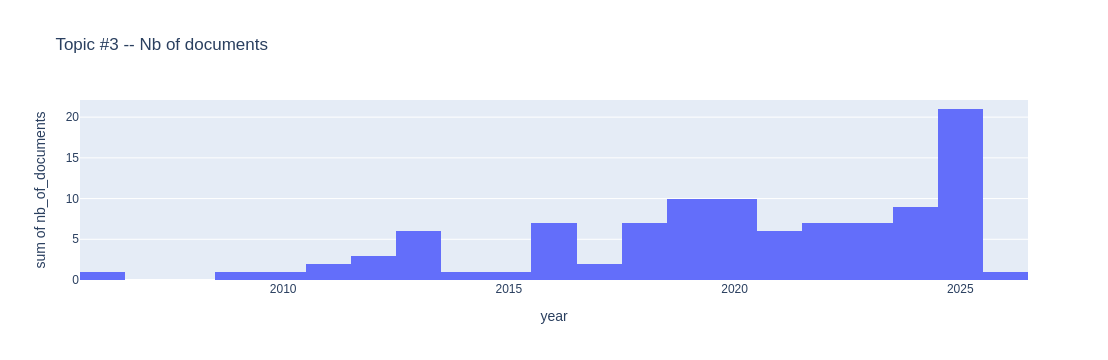

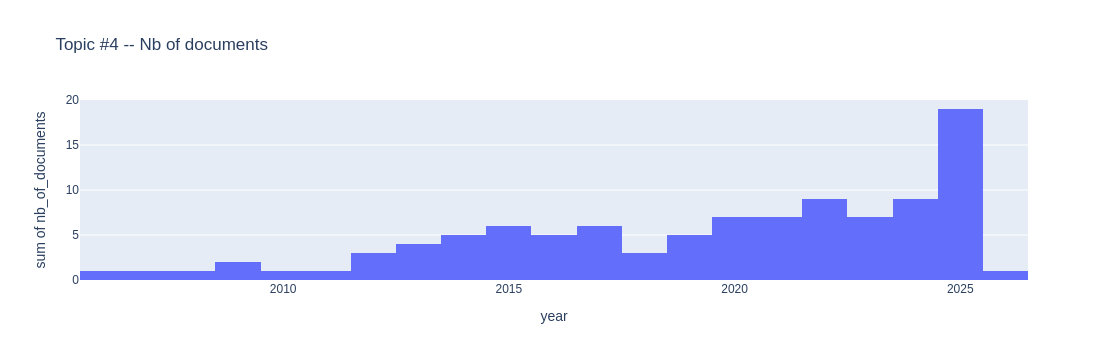

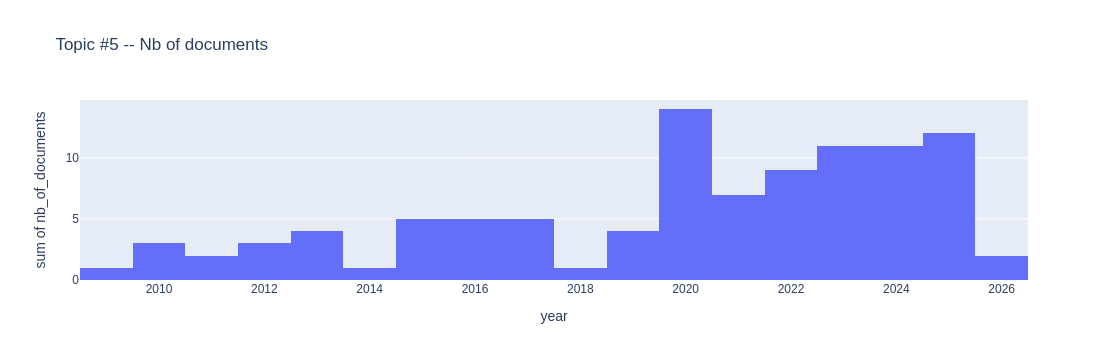

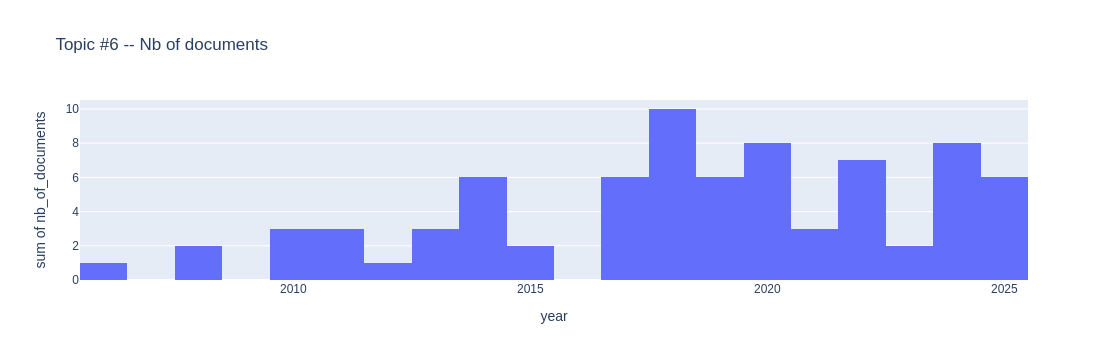

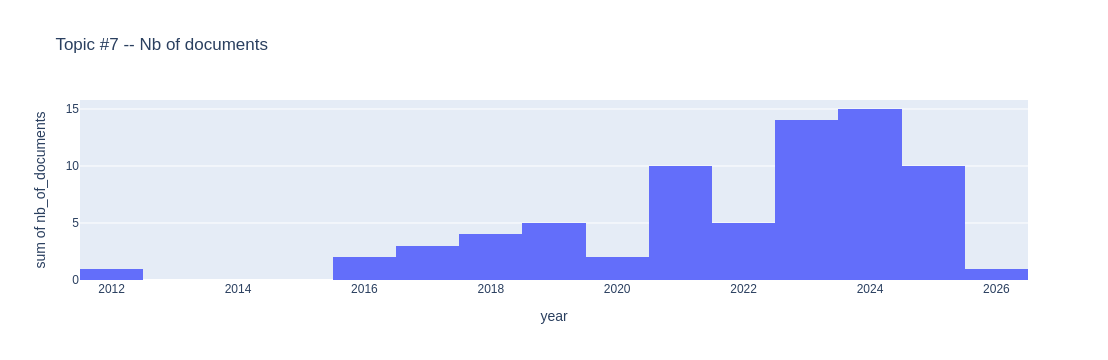

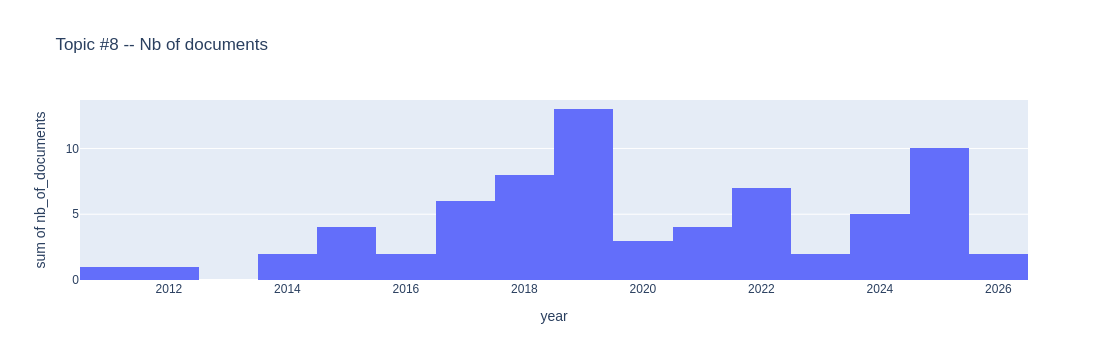

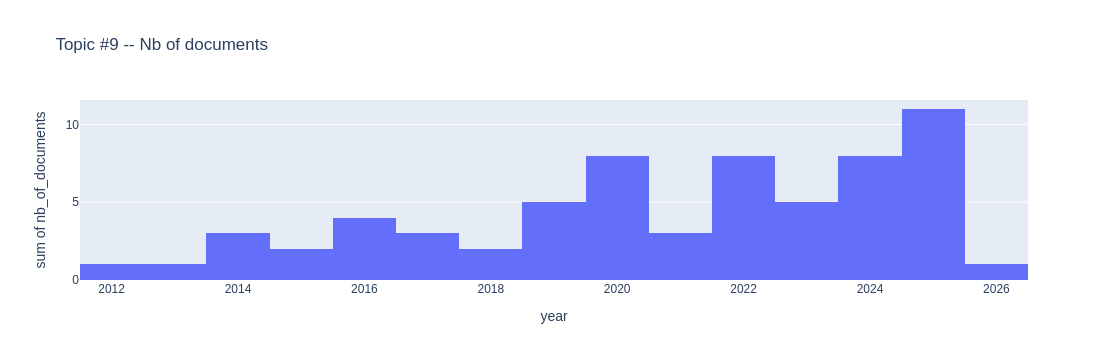

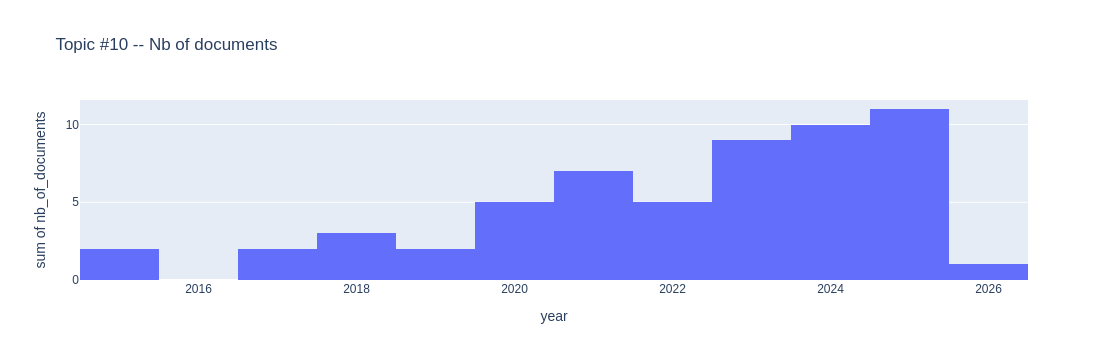

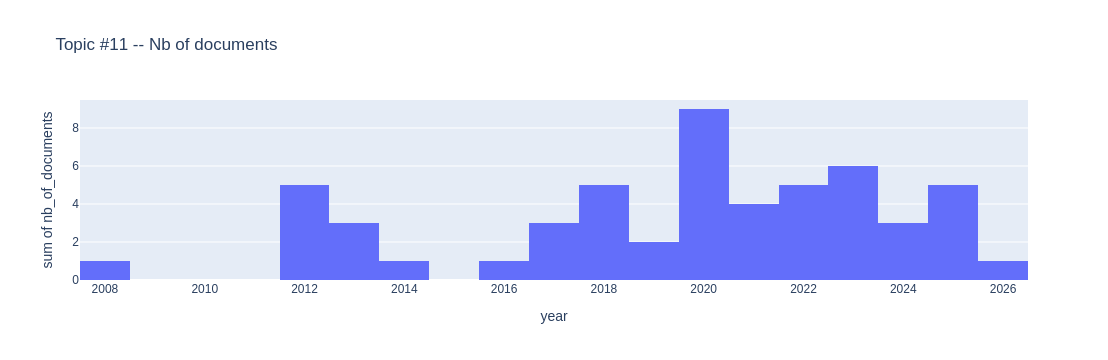

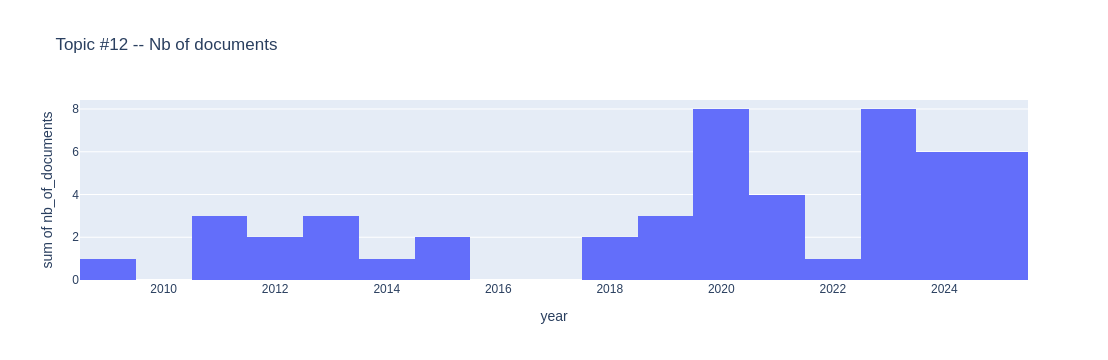

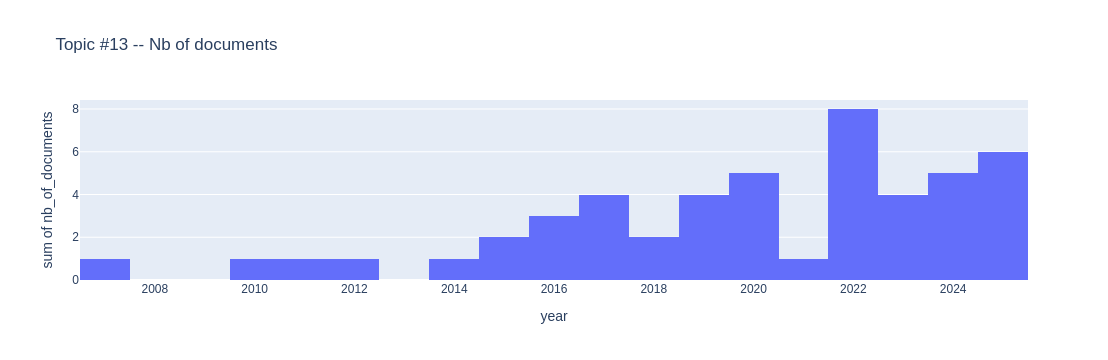

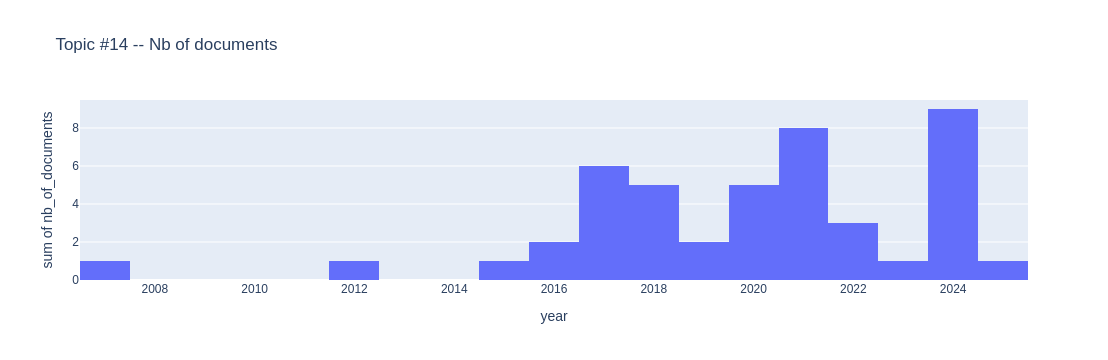

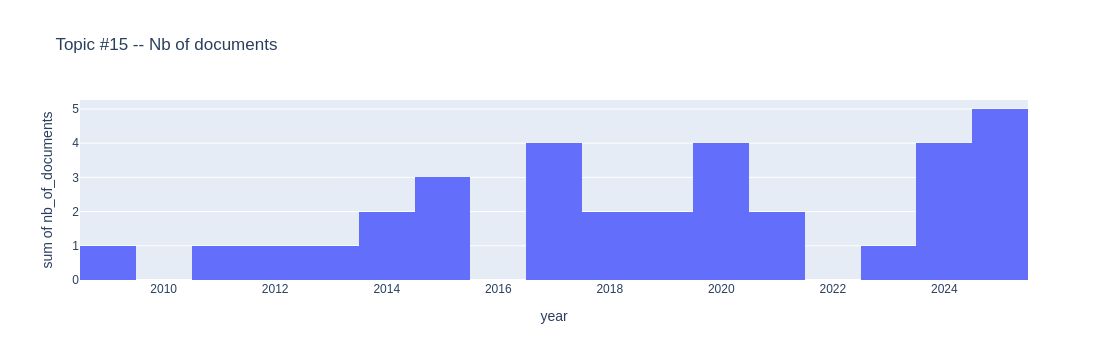

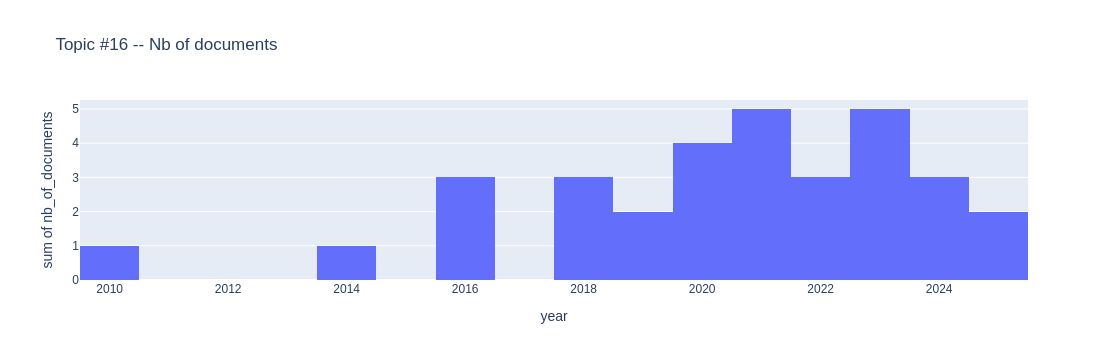

In [24]:
import numpy as np
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots

hdbscan_cluster_method = "leaf"
doc_type = "articles"

topic_size = 32
min_samples = 2
neighbors = 10
components = 15

year_aggregate = 2  # Aggregate histograms by {year_aggregate} years

input_dir = f"./SPECTER_2/INCLUDED/{doc_type.upper()}/neighbors={neighbors}_components={components}/{hdbscan_cluster_method.upper()}"
bertopic_results = pd.read_csv(input_dir + f"/bertopic_results_topic_size={topic_size}_min_samples={min_samples}.csv", index_col=0)
bertopic_results["nb_of_documents"] = 1
nb_of_topics = bertopic_results["Topic"].max() + 1
topic = dict()

fig = make_subplots(rows=nb_of_topics, cols=1)

for topic_nb in range(nb_of_topics):
    topic[topic_nb] = bertopic_results.loc[bertopic_results["Topic"] == topic_nb, :]
    nbins = int(topic[topic_nb]["year"].max() - topic[topic_nb]["year"].min() + 1)
    #fig.add_histogram(px.histogram(topic[topic_nb], x="year", y="Topic"), row=topic_nb, col=1)
    fig = px.histogram(topic[topic_nb], x="year", y="nb_of_documents",
                       title=f"Topic #{topic_nb} -- Nb of documents",
                       nbins=nbins)
    fig.show()

### Remove outliers

In [25]:
bertopic_results_wo_outliers = bertopic_results.loc[bertopic_results["Topic"]!=-1, :]

### Number of documents per topic (absolute, normalized and weighted)

In [26]:
nb_docs_per_topics = np.asarray([len(topic[n_topic]) for n_topic in bertopic_results_wo_outliers["Topic"]])
bertopic_results_wo_outliers = bertopic_results_wo_outliers.assign(nb_docs_per_topic=nb_docs_per_topics)
bertopic_results_wo_outliers = bertopic_results_wo_outliers.assign(normalize_nb_of_docs=1/nb_docs_per_topics)
# bertopic_results_wo_outliers.loc[:, "nb_of_docs_per_topic"] = nb_docs_per_topics
# bertopic_results_wo_outliers.loc[:, "normalize_nb_of_docs"] = 1/nb_docs_per_topics

## Dynamic analysis

### Absolute nb of documents per topic over time

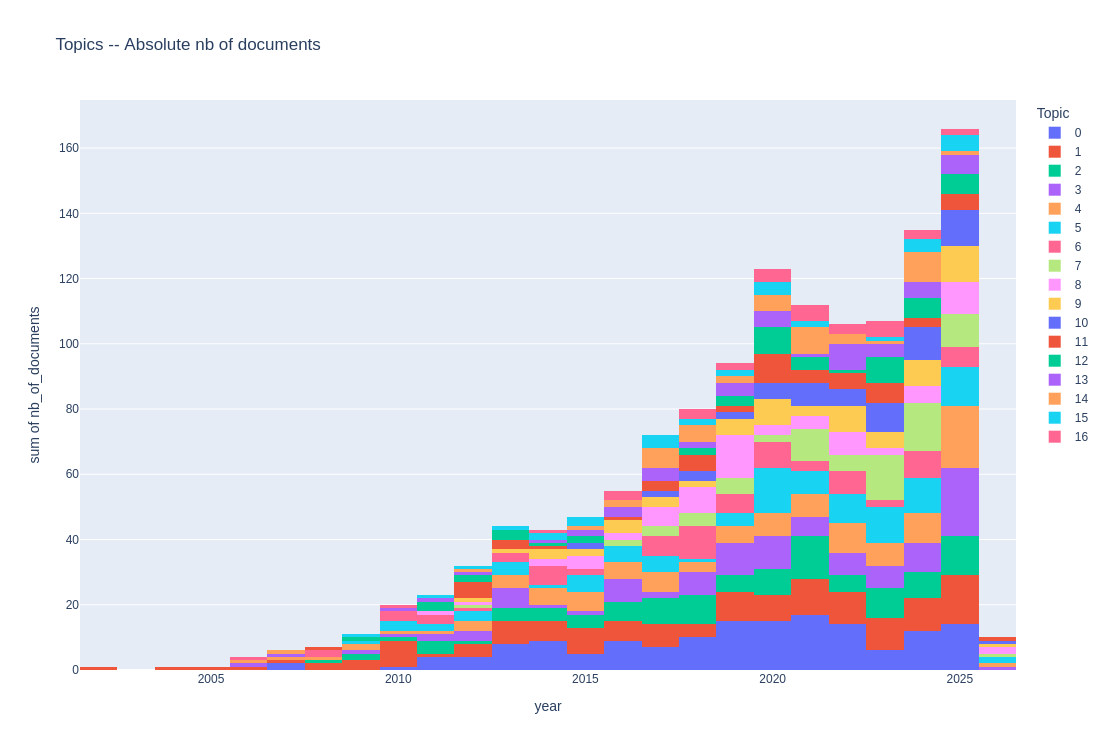

In [59]:
fig = px.histogram(bertopic_results_wo_outliers.sort_values(by=["Topic"]), x="year", y="nb_of_documents", color="Topic",
                   title=f"Topics -- Absolute nb of documents",
                   nbins=30)
fig.update_layout(
    width = 850,
    height = 750,
)
fig.show()

#### Cumulative

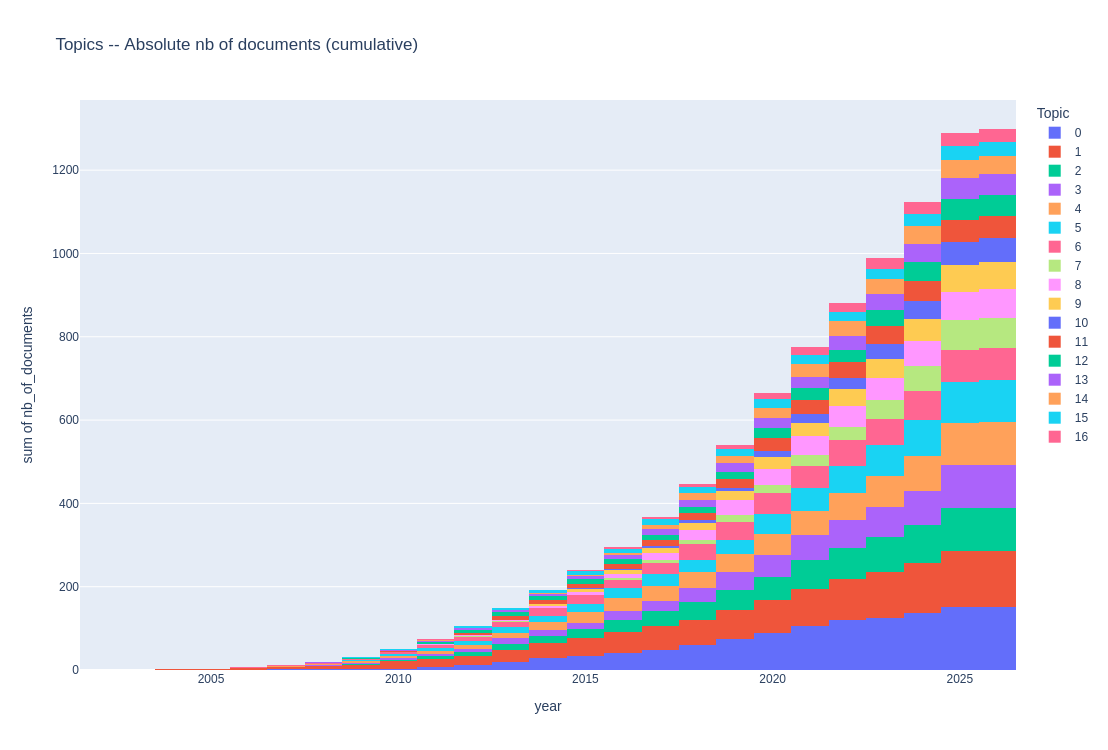

In [61]:
fig = px.histogram(bertopic_results_wo_outliers.sort_values(by=["Topic"]), x="year", y="nb_of_documents", color="Topic",
                   title=f"Topics -- Absolute nb of documents (cumulative)", cumulative=True,
                   nbins=30)
fig.update_layout(
    width = 850,
    height = 750,
)
fig.show()

### Normalized nb of documents per topic over time

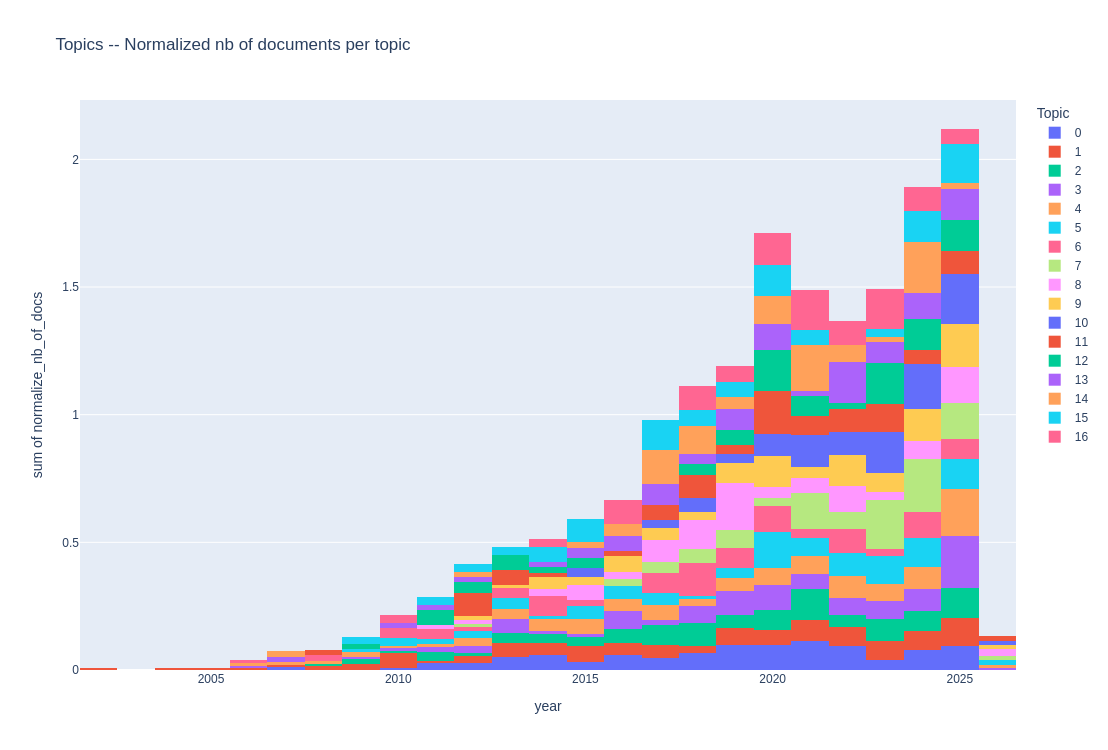

In [28]:
fig = px.histogram(bertopic_results_wo_outliers.sort_values(by=["Topic"]), x="year", y="normalize_nb_of_docs", color="Topic",
                   title=f"Topics -- Normalized nb of documents per topic",
                   nbins=30)
fig.update_layout(
    width = 850,
    height = 750,
)
fig.show()

### Weighted normalized nb of docs per topic over time

In [56]:
df_long = pd.concat([bertopic_results_wo_outliers.loc[:, ["ID", "year"]], bertopic_results_wo_outliers.loc[:, "topic#0":"topic#16"]], axis=1)
df_long.rename(columns={f"topic#{n}" : n for n in range(nb_of_topics)}, inplace=True)
df_long = df_long.melt(id_vars=["ID", "year"], var_name="topic", value_name="weight")

df_agg = (df_long
          .groupby(["year", "topic"], as_index=False)["weight"]
          .sum()
          .rename(columns={"weight": "weighted_count"}))

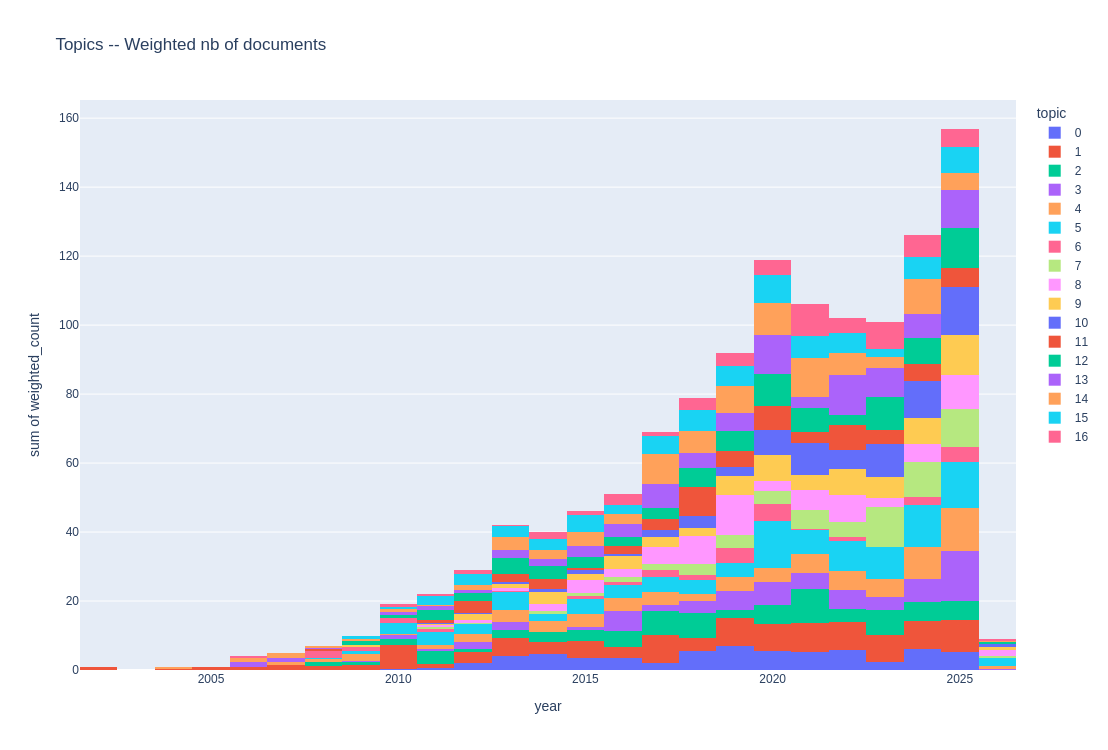

In [57]:
fig = px.histogram(df_agg.sort_values(by=["topic"]), x="year", y="weighted_count", color="topic",
                   title=f"Topics -- Weighted nb of documents",
                   nbins=30)
fig.update_layout(
    width = 850,
    height = 750,
)
fig.show()

### Nb of documents per topic

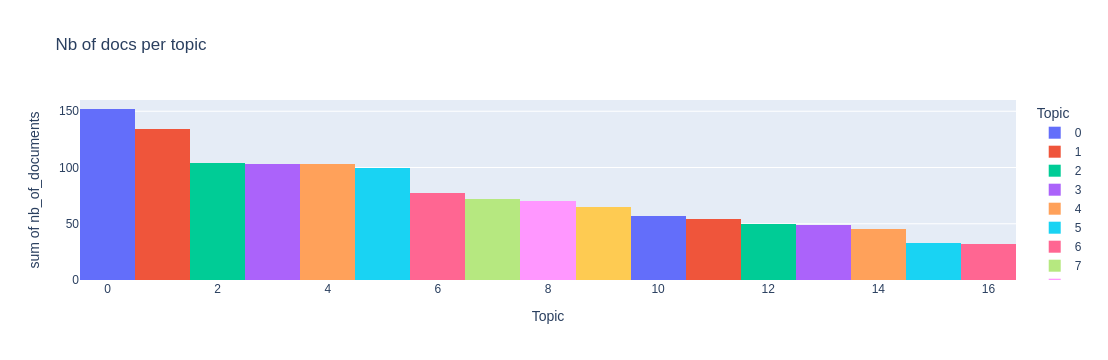

In [29]:
fig = px.histogram(bertopic_results_wo_outliers.sort_values(by="Topic"), x="Topic", y="nb_of_documents", color="Topic",
                   title="Nb of docs per topic")
fig.show()

### Citation count per topic

#### Absolute nb of citations

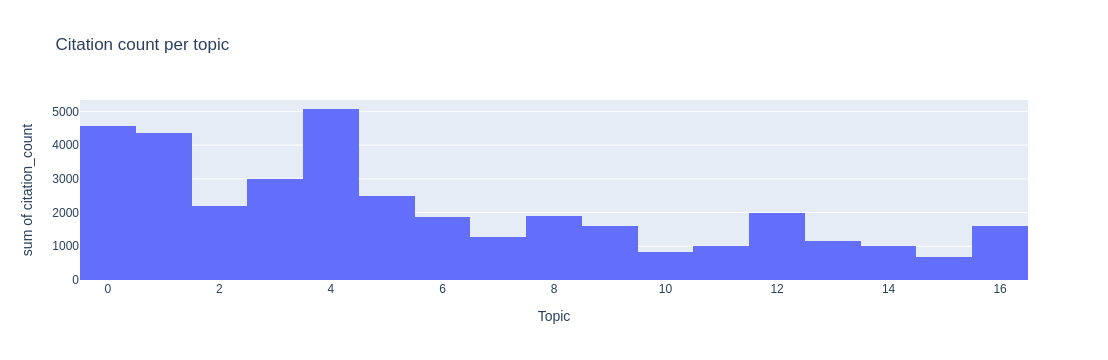

In [30]:
fig = px.histogram(bertopic_results_wo_outliers, x="Topic", y ="citation_count",
                   title="Citation count per topic")
fig.show()

#### Normalize by nb of documents

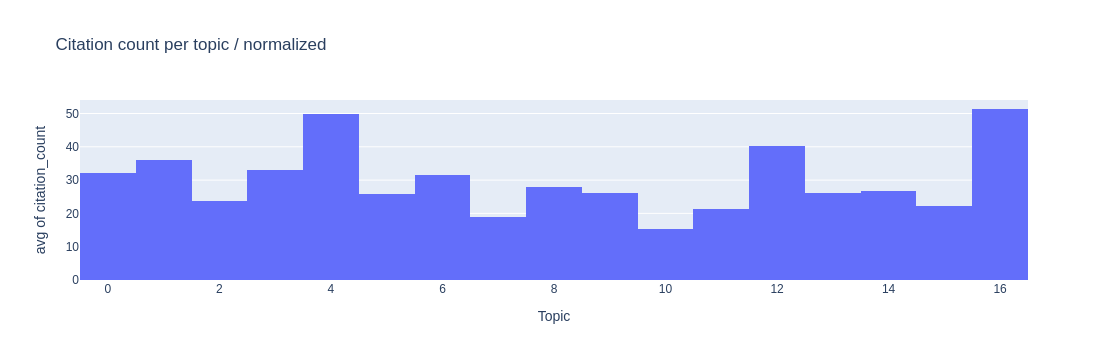

In [31]:
fig = px.histogram(bertopic_results_wo_outliers, x="Topic", y="citation_count", histfunc="avg", 
                   title="Citation count per topic / normalized")
fig.show()

## Adjust for the {n} most cited documents

In [32]:
n_most_cited = 5
bertopic_results_wo_outliers_most_cited = bertopic_results_wo_outliers.sort_values(['citation_count', 'Topic'],ascending=False).groupby('Topic').head(n_most_cited)

### Citations per topic

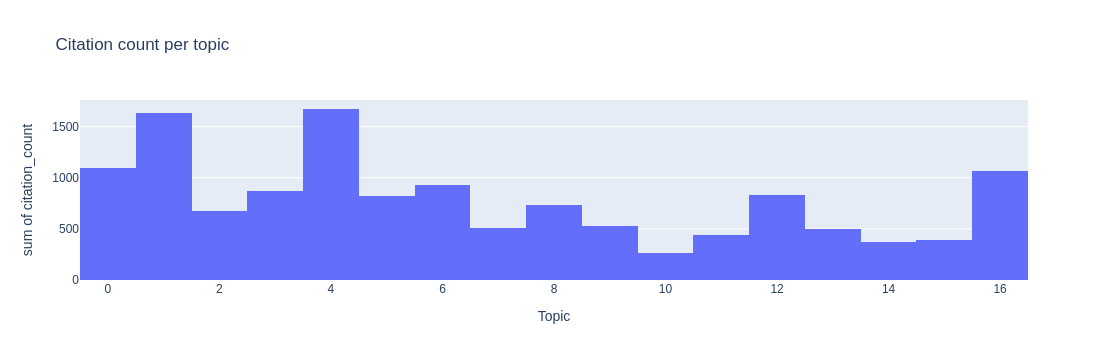

In [33]:
fig = px.histogram(bertopic_results_wo_outliers_most_cited, x="Topic", y ="citation_count",
                   title="Citation count per topic", nbins=nb_of_topics)
fig.show()

## Extract {n} most cited articles and look at topics

We may extract the 100 most cited articles and look which are the topics that are represented within this set

In [66]:
n_most_cited = 50
most_cited_docs = bertopic_results_wo_outliers.sort_values(by="citation_count", ascending=False).iloc[:n_most_cited, :]

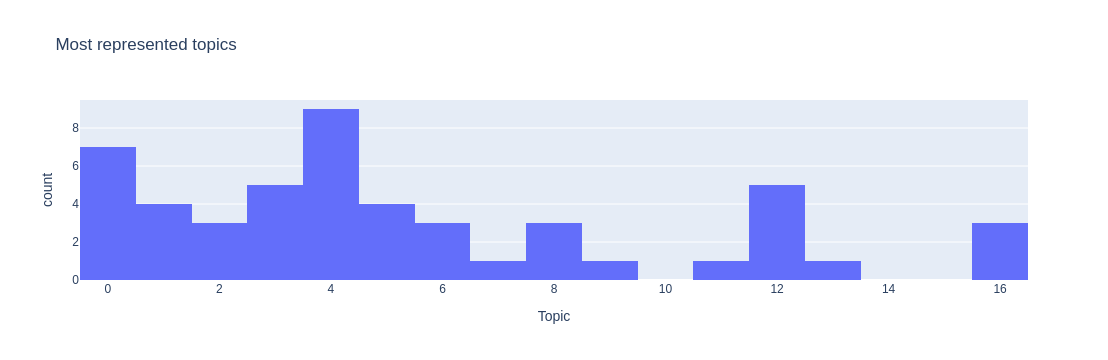

In [67]:
fig = px.histogram(most_cited_docs, x="Topic",
                   title="Most represented topics", nbins=nb_of_topics)
fig.show()

## Cosine similarity between topics 2x2
* Co-occurence mesh between topic "column" vectors
* $$\cos(i,j) = \frac{v_i^Tv_j}{\lVert v_i \rVert \lVert v_j \rVert} = \frac{\sum_d p_{d,i}p_{d,j}}{\sqrt{\sum_d p^2_{d,i}}\sqrt{\sum_d p^2_{d,j}}}$$

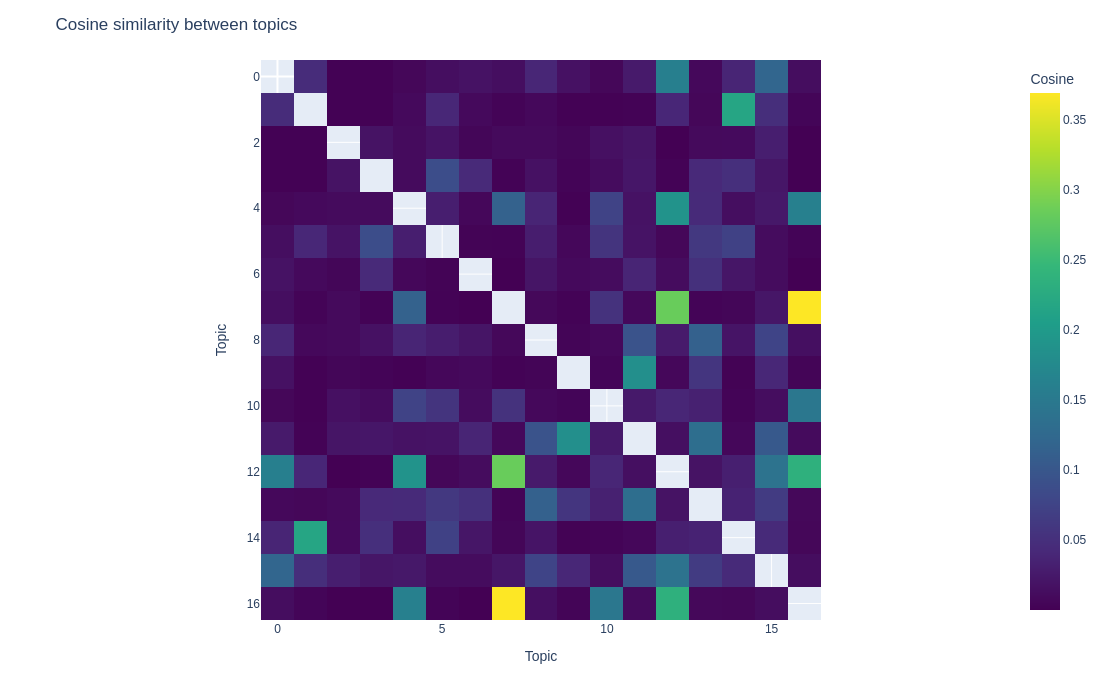

In [36]:
import plotly.express as px
from sklearn.metrics.pairwise import cosine_similarity

docs_topics_array = bertopic_results_wo_outliers.loc[:, "topic#0":f"topic#{nb_of_topics - 1}"]
cos_similarity = cosine_similarity(docs_topics_array.T)

cos_similarity[cos_similarity > 0.999] = np.nan

fig = px.imshow(
    cos_similarity,
    color_continuous_scale="Viridis",
    # zmin=0, zmax=1,
    labels=dict(x="Topic", y="Topic", color="Cosine"),
)
fig.update_layout(
    title="Cosine similarity between topics",
    width=800, height=700
)
fig.show()